# Representation Learning en PyTorch

Este notebook tiene como objetivo ilustrar cómo una red neuronal poco profunda puede resolver un problema de clasificación no lineal aprendiendo no solo una frontera de decisión, sino también una transformación de los datos de entrada hacia un espacio latente más adecuado para la separación entre clases.


In [1]:
# Librerías numéricas y de visualización
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

# Colores parecidos a la figura
region_cmap = ListedColormap([
    "#d9d8ee",  # lavanda claro (región exterior)
    "#eadfce"   # beige claro (región interior)
])

point_colors = ["#0000ff", "#ff7f0e"]  # azul y naranja


# Datos de ejemplo
from sklearn import datasets

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Para reproducibilidad
np.random.seed(1)
torch.manual_seed(1)


## Creación del conjunto de datos y definición de funciones para gráficas

In [2]:
# Función para graficar la frontera de decisión
def plot_predictions_torch(model, axes):
    x0s = np.linspace(axes[0], axes[1], 200)
    x1s = np.linspace(axes[2], axes[3], 200)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_grid = np.c_[x0.ravel(), x1.ravel()]

    X_grid_tensor = torch.tensor(X_grid, dtype=torch.float32)
    with torch.no_grad():
        y_prob = model(X_grid_tensor).numpy().reshape(x0.shape)

    y_class = (y_prob >= 0.5).astype(float)
    plt.contourf(x0, x1, y_class, cmap=region_cmap, alpha=1)


Forma de x: (1000, 2)
Forma de y: (1000,)


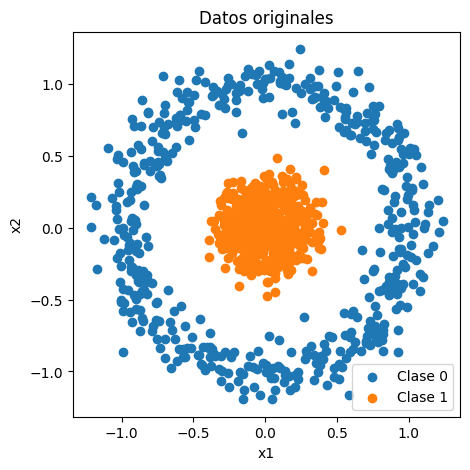

In [3]:
# Crear un conjunto de datos no lineal: dos círculos concéntricos
x, y = datasets.make_circles(
    n_samples=1000,
    noise=0.1,
    factor=0.2,
    random_state=1
)

print('Forma de x:', x.shape)
print('Forma de y:', y.shape)

plt.figure(figsize=(5,5))
plt.scatter(x[y==0, 0], x[y==0, 1], label='Clase 0')
plt.scatter(x[y==1, 0], x[y==1, 1], label='Clase 1')
plt.title('Datos originales')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()


In [4]:
# Convertir los datos a tensores de PyTorch
X_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

print('Tensor de entrada:', X_tensor.shape)
print('Tensor de salida:', y_tensor.shape)


Tensor de entrada: torch.Size([1000, 2])
Tensor de salida: torch.Size([1000, 1])


## Definición de la red neuronal con dos capas ocultas

In [5]:
# Definimos una red poco profunda con una capa oculta
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(2, 4) # Capa oculta 1
        self.hidden2 = nn.Linear(4, 2) # Capa oculta 2
        self.classifier = nn.Sequential(
            nn.Linear(2, 1),
            nn.Sigmoid()
        ) # Capa de clasificación
        self.relu = nn.ReLU()

    def forward(self, x): # Se define el funcionamiento de la red
        z1 = self.relu(self.hidden1(x)) # la primera capa oculta tiene como
        # entrada los datos crudos
        z2 = self.relu(self.hidden2(z1)) # Luego, la segunda capa oculta recibe
        # la salida de la primera capa.
        y_hat = self.classifier(z2) # Finalmente, la última etapa corresponde a
        # un clasificador lineal (regresión logística).
        return y_hat

    def latent_representation(self, x):
        # Esta función es auxiliar, no hace parte del entrenamiento de la red.
        # Se usa para visualizar como las capas ocultas de la red transforman los
        # datos para mejorar su representación.
        z1 = self.relu(self.hidden1(x))
        z2 = self.relu(self.hidden2(z1))
        return z2

# Se inicializa el modelo.
model = SimpleNet()
print(model)


SimpleNet(
  (hidden1): Linear(in_features=2, out_features=4, bias=True)
  (hidden2): Linear(in_features=4, out_features=2, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=2, out_features=1, bias=True)
    (1): Sigmoid()
  )
  (relu): ReLU()
)


In [6]:
# Función de costo y optimizador
criterion = nn.BCELoss() # Se elige una fúnción de costo adecuada para el problema
# de clasificación binaria.
optimizer = optim.SGD(model.parameters(), lr=0.05) # El optimizador que lleva a
# cabo el gradiente descendente.

In [7]:
# Entrenamiento del modelo
num_epochs = 2000
loss_history = [] # Guardar el progreso de la función de costo. Esto es vital
# en cualquier red neuronal.

for epoch in range(num_epochs):
    # 1. Poner gradientes en cero
    optimizer.zero_grad()

    # 2. Propagación hacia adelante
    y_pred = model(X_tensor)

    # 3. Calcular pérdida
    loss = criterion(y_pred, y_tensor)

    # 4. Retropropagación
    loss.backward()

    # 5. Actualización de parámetros
    optimizer.step()

    loss_history.append(loss.item())

    # Imprimir la función de costo cada 25 épocas
    if (epoch + 1) % 25 == 0:
        print(f'Época {epoch+1:3d}/{num_epochs} - Función de costo: {loss.item():.6f}')


Época  25/2000 - Función de costo: 0.692370
Época  50/2000 - Función de costo: 0.688110
Época  75/2000 - Función de costo: 0.684619
Época 100/2000 - Función de costo: 0.682080
Época 125/2000 - Función de costo: 0.679802
Época 150/2000 - Función de costo: 0.677431
Época 175/2000 - Función de costo: 0.674850
Época 200/2000 - Función de costo: 0.671953
Época 225/2000 - Función de costo: 0.668670
Época 250/2000 - Función de costo: 0.664949
Época 275/2000 - Función de costo: 0.660754
Época 300/2000 - Función de costo: 0.656068
Época 325/2000 - Función de costo: 0.650907
Época 350/2000 - Función de costo: 0.645310
Época 375/2000 - Función de costo: 0.639323
Época 400/2000 - Función de costo: 0.633027
Época 425/2000 - Función de costo: 0.626563
Época 450/2000 - Función de costo: 0.620080
Época 475/2000 - Función de costo: 0.613710
Época 500/2000 - Función de costo: 0.607560
Época 525/2000 - Función de costo: 0.601761
Época 550/2000 - Función de costo: 0.596376
Época 575/2000 - Función de cost

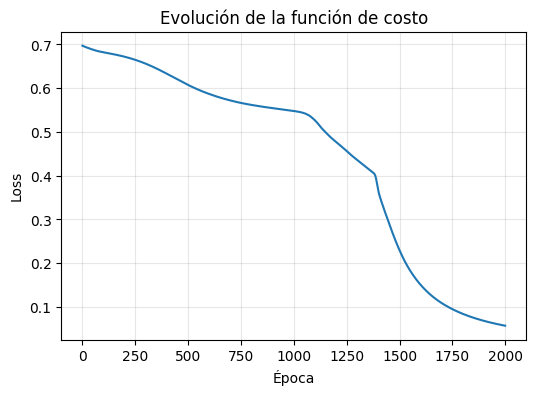

In [8]:
# Curva de entrenamiento
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title('Evolución de la función de costo')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()


In [9]:
# Evaluación simple del modelo
with torch.no_grad():
    probs = model(X_tensor)
    preds = (probs >= 0.5).float()
    accuracy = (preds.eq(y_tensor).sum().item()) / len(y_tensor)

print(f'Exactitud sobre el conjunto de entrenamiento: {accuracy:.4f}')


Exactitud sobre el conjunto de entrenamiento: 0.9990


## Visualización

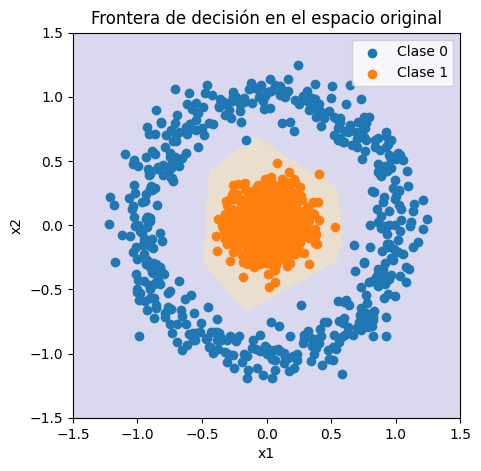

In [10]:
# Visualización en el espacio original
plt.figure(figsize=(5,5))
plot_predictions_torch(model, [-1.5, 1.5, -1.5, 1.5])
plt.title('Frontera de decisión en el espacio original')
plt.scatter(x[y==0,0], x[y==0,1], label='Clase 0')
plt.scatter(x[y==1,0], x[y==1,1], label='Clase 1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()



In [11]:
# Extraer la representación latente de dimensión 2
with torch.no_grad():
    z_l_1 = model.latent_representation(X_tensor).numpy()

print('Forma de la representación latente:', z_l_1.shape)
z_l_1[:5]


Forma de la representación latente: (1000, 2)


array([[0.        , 0.070907  ],
       [0.        , 0.        ],
       [0.30355865, 2.4358227 ],
       [0.15889876, 1.4279206 ],
       [0.        , 3.1120691 ]], dtype=float32)

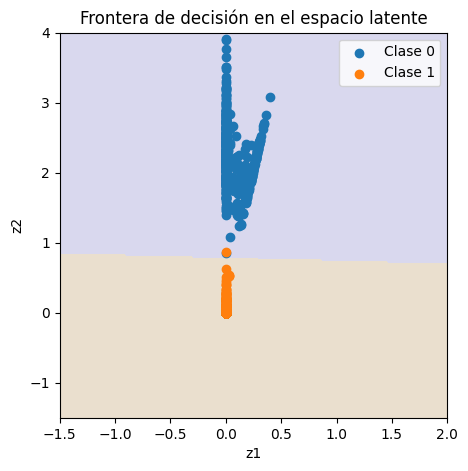

In [12]:
# Visualización en el espacio latente
plt.figure(figsize=(5,5))
plot_predictions_torch(model.classifier, [-1.5, 2, -1.5, 4])
plt.title('Frontera de decisión en el espacio latente')
plt.scatter(z_l_1[y==0,0], z_l_1[y==0,1], label='Clase 0')
plt.scatter(z_l_1[y==1,0], z_l_1[y==1,1], label='Clase 1')

plt.xlabel('z1')
plt.ylabel('z2')
plt.legend()
plt.show()